In [114]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [115]:
df = pd.read_csv('cw_data.csv', header = None)

###Data Exploration

In [116]:
df.head()

,0,1
0,tracking shows shipped but no delivery help pls,shipping_delay
1,partial shipments tracked separately?,order_tracking
2,invalid email entered wat happens?,update_email
3,recover acct if suspended?,account_recovery
4,emial update failed error — fix?,update_email


In [117]:
classes = np.array(df[1].tolist())
unique, counts = np.unique(classes, return_counts=True)
print(np.asarray((unique, counts)).T)

[['account_recovery' '21']
 ['billing_history' '21']
 ['data_privacy' '22']
 ['delete_account' '23']
 ['login_issue' '16']
 ['notification_settings' '24']
 ['order_tracking' '22']
 ['payment_issue' '33']
 ['refund_request' '21']
 ['reset_password' '20']
 ['shipping_delay' '29']
 ['subscription_management' '23']
 ['two_factor_auth' '10']
 ['update_email' '23']]


###Class Imbalance

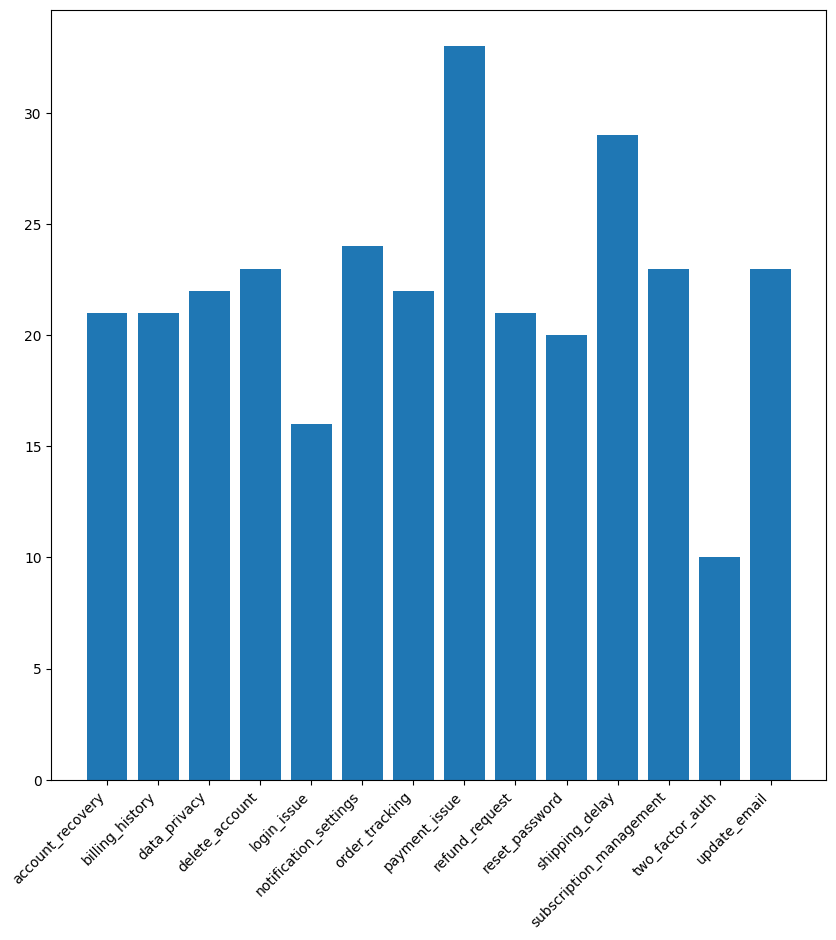

In [118]:
fig, ax = plt.subplots(figsize=(10, 10))

plt.bar(unique, counts, )
plt.xticks(rotation = 45, ha = 'right')
plt.show()

###Remove Capitals

In [119]:
def lowercase(text):
  return text.lower()

###Tokenise

In [120]:
import spacy

In [121]:
nlp = spacy.load("en_core_web_sm")

def tokenise(text):
  processed_doc = nlp(text)
  return processed_doc


In [122]:
def stopword_removal(document):
  filtered_tokens = [token for token in document if not token.is_stop]
  return filtered_tokens
print(f"Original:{df[0][3]} | Cleaned: {stopword_removal(nlp(df[0][3]))}")

Original:recover acct if suspended? | Cleaned: [recover, acct, suspended, ?]


In [123]:
def lemmatise(document):
  lematised_tokens = [token.lemma_ for token in document]
  return lematised_tokens
print(f"Original:{df[0][4]} | Cleaned: {lemmatise(nlp(df[0][4]))}")

Original:emial update failed error — fix? | Cleaned: ['emial', 'update', 'fail', 'error', '—', 'fix', '?']


###Analyse what punctuation marks there are:

In [124]:
import string

In [125]:
abc = list(string.ascii_lowercase) + list(string.ascii_uppercase)
punc = []
for doc in df[0]:
  for character in doc:
    if character not in abc and character != ' ' and not character.isnumeric():
      punc.append(character)
punc = np.array(punc)
unique, counts = np.unique(punc, return_counts=True)
print(np.asarray((unique, counts)).T)

[['!' '2']
 ['&' '3']
 ["'" '16']
 ['(' '7']
 [')' '7']
 ['-' '7']
 ['.' '8']
 ['/' '8']
 [':' '3']
 [';' '10']
 ['?' '285']
 ['—' '48']
 ['…' '6']
 ['→' '3']]


In [126]:
def check_punctuation(punc):
  query = []
  for i, row in df.iterrows():
    if punc in row[0]:
      query.append(row[1])
  query = np.array(query)
  print(f"There are {query.size} queries with '{punc}'")
  unique, counts = np.unique(query, return_counts=True)
  print(np.asarray((unique, counts)).T)
check_punctuation("(")

There are 7 queries with '('
[['login_issue' '3']
 ['reset_password' '3']
 ['two_factor_auth' '1']]


Can't see any semantic benefit for keeping punctuation



In [127]:
punc = string.punctuation + "→" + "—" + "…"

def remove_punctuation(document):
  translator = str.maketrans('', '', punc)
  clean_text = document.translate(translator)
  return clean_text
print(f"Original:{df[0][4]} | Cleaned: {remove_punctuation(df[0][4])}")


Original:emial update failed error — fix? | Cleaned: emial update failed error  fix


In [128]:
def whitespace_removal(document):
  return document.replace('  ', ' ')

###Put it all together

In [129]:
def preprocess(document):
  x = lowercase(document)
  x = remove_punctuation(x)
  x = whitespace_removal(x)
  x = nlp(x)
  x = stopword_removal(x)
  x = lemmatise(x)


  return x

In [130]:
df2 = df.copy(deep = True)
for i, row in df2.iterrows():
  row[0] = preprocess(row[0])


In [131]:
print(f"{df[0][4]}{df2[0][4]}")

emial update failed error — fix?['emial', 'update', 'fail', 'error', 'fix']


Binary bag-of-unigrams and TF-IDF

In [132]:
def bag_of_unigrams(documents):
  vocabulary = {}
  dataset = []
  for d in documents:
    for word in d:
      if word not in vocabulary:
        vocabulary[word] = len(vocabulary)

  for d in documents:
    feature_vector = [0] * len(vocabulary)

    for word in d:
      if word in vocabulary:
        feature_vector[vocabulary[word]] = 1
    dataset.append(feature_vector)
  return dataset, vocabulary

In [133]:
unigrams = bag_of_unigrams(df2[0])[0]


In [134]:
def tfidf_transformation(feature_vectors):
  transformed_feature_vectors = []
  # Let's transform the feature vectors into a matrix
  feature_vectors = np.array(feature_vectors)

  vocab_size = len(feature_vectors[0])
  num_documents = len(feature_vectors)
  transformed_feature_vectors = np.zeros((num_documents, vocab_size))
  #IDF IMPLEMENTATION
  idf = []
  doc_containing_t = np.zeros(vocab_size)
  for vector in feature_vectors:
    for i_2, element in enumerate(vector):
      if vector[i_2] > 0:
        doc_containing_t[i_2] += 1
  for t in range(vocab_size):
    idf.append(np.log(num_documents / doc_containing_t[t]))

  #TF IMPLEMENTATION
  tf = np.zeros((num_documents, vocab_size))
  for i_1, vector in enumerate(feature_vectors):
    #terms = len(vector[vector != 0 ])
    terms = np.sum(vector)
    for i_2, element in enumerate(vector):
      tf[i_1][i_2] = element/terms

  #MULTIPLYING TF AND IDF
  for i_1, vector in enumerate(transformed_feature_vectors):
    for i_2, element in enumerate(vector):
      transformed_feature_vectors[i_1][i_2] = tf[i_1][i_2] * idf[i_2]


  return transformed_feature_vectors

In [135]:
tfidf = tfidf_transformation(unigrams)

###Classification

In [136]:
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.model_selection import train_test_split, GridSearchCV


In [137]:
X_train, X_test, y_train, y_test = train_test_split(tfidf, df2[1], train_size = 0.75, random_state = 32)

Hyperparameter Optimisation

In [138]:
base_model = ComplementNB()

parameters = {
    'alpha': [i*0.01 for i in range(1,101)],
    'norm' : [True, False]
}



In [139]:
grid_search = GridSearchCV(
    estimator = base_model,
    param_grid = parameters,
    cv = 2,
    scoring = 'f1_macro',
    n_jobs = 1
)

In [140]:
grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_

In [141]:
grid_search.best_params_

{'alpha': 1.0, 'norm': True}

In [142]:
predictions = best_model.predict(X_test)

In [143]:
print(f"{predictions[0]} | {y_test.tolist()[0]}")

account_recovery | account_recovery


###Evaluation

In [144]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

In [145]:
report = classification_report(predictions, y_test.tolist())

In [146]:
print(report)

                         precision    recall  f1-score   support

       account_recovery       1.00      0.75      0.86         4
        billing_history       1.00      0.78      0.88         9
           data_privacy       0.83      1.00      0.91         5
         delete_account       0.60      0.86      0.71         7
            login_issue       0.75      1.00      0.86         3
  notification_settings       0.67      0.67      0.67         3
         order_tracking       1.00      0.83      0.91         6
          payment_issue       0.90      1.00      0.95         9
         refund_request       1.00      0.33      0.50         3
         reset_password       1.00      0.89      0.94         9
         shipping_delay       0.75      1.00      0.86         6
subscription_management       0.62      0.83      0.71         6
        two_factor_auth       1.00      1.00      1.00         3
           update_email       1.00      0.25      0.40         4

               accuracy

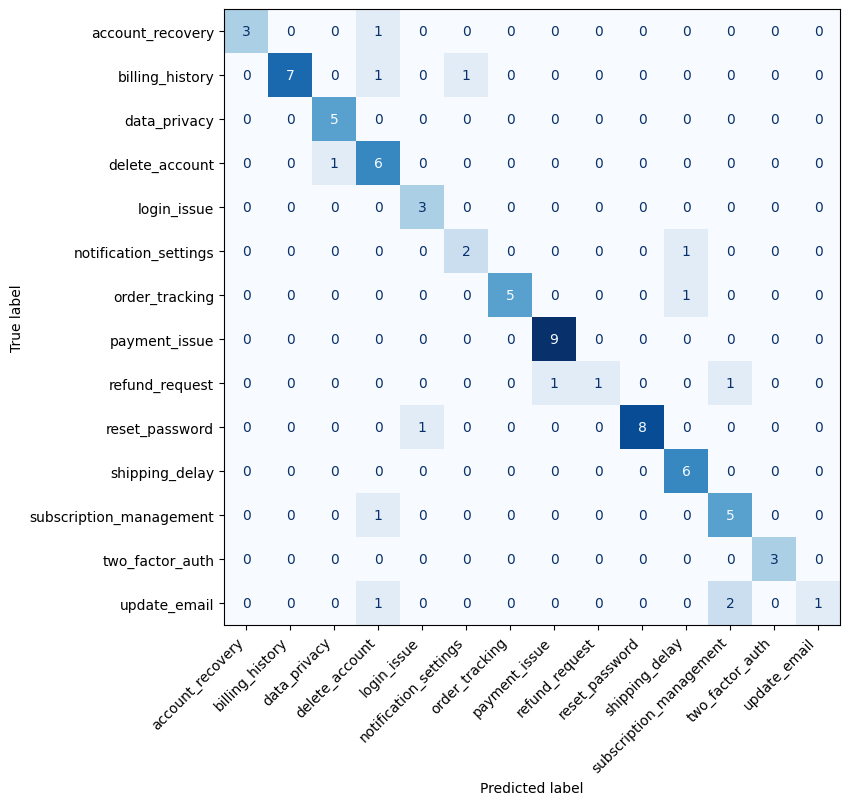

In [147]:
confusion = confusion_matrix(predictions, y_test.tolist(), labels = best_model.classes_)
fig, ax = plt.subplots(figsize=(8, 8))

disp = ConfusionMatrixDisplay(confusion, display_labels = best_model.classes_)
disp.plot(ax = ax, cmap = 'Blues', colorbar = False)

plt.xticks(rotation = 45, ha = 'right')
plt.show()

###Check example incorrect predictions

In [148]:
example_results = pd.DataFrame({'Raw_Text': df.loc[y_test.index, 0],
                                'Processed_Text': df2.loc[y_test.index, 0],
                                'True_Label': y_test,
                                'Predicted_Label': predictions
                                })
example_results[example_results['Predicted_Label'] != example_results['True_Label']]

,Raw_Text,Processed_Text,True_Label,Predicted_Label
117,confirmation after deletion — will i get?,"[confirmation, deletion]",delete_account,update_email
258,why courier not updating tracking info?,"[courier, update, tracking, info]",shipping_delay,order_tracking
177,link multiple subscriptions 1 acct possible?,"[link, multiple, subscription, 1, acct, possible]",subscription_management,update_email
216,shipping notification not received wat 2 do?,"[shipping, notification, receive, wat, 2]",shipping_delay,notification_settings
29,delete acct also deletes purchase history?,"[delete, acct, delete, purchase, history]",delete_account,billing_history
118,upgrade plan mobile vs desktop?,"[upgrade, plan, mobile, vs, desktop]",subscription_management,update_email
172,refund mid-cycle possible?,"[refund, midcycle, possible]",subscription_management,refund_request
241,use multiple payment methods for 1 order possi...,"[use, multiple, payment, method, 1, order, pos...",payment_issue,refund_request
292,I get a 'credentials incorrect' message even t...,"[credential, incorrect, message, password, cor...",login_issue,reset_password
103,recover acct after deletion possible?,"[recover, acct, deletion, possible]",delete_account,account_recovery
